### ***Laboratório 7 – Processamento Morfológico de Imagens***
<br>
31/03/2026 - Sexta-Feira
<br>
Atividades Experimentais
<br>

### ***Integrantes:***
<br>
Ronaldo Ávila de Arruda Junior 11202231908
<br>
Leonardo Garcia dos Santos 11202230441

### ***Introdução***

O presente relatório, desenvolvido no âmbito da disciplina de Processamento Digital de Imagens, foca-se no Processamento Morfológico de Imagens. A morfologia matemática aplicada a imagens é uma ferramenta essencial na extração de componentes visuais que são úteis para a representação e descrição da forma das regiões.

Este documento descreve detalhadamente os procedimentos experimentais realizados, onde as operações fundamentais de erosão, dilatação, abertura e fechamento foram aplicadas e analisadas. Ao longo do relatório, será relatada a aplicação destas operações em imagens dos membros do grupo e dos seus avatares, incluindo uma discussão sobre a influência da binarização prévia nos resultados obtidos. Adicionalmente, o relatório ilustra a utilização de técnicas morfológicas para a eliminação de ruído em imagens ruidosas (como uma impressão digital), a extração de fronteiras em tempo real através da webcam utilizando o Gradiente Morfológico, e, por fim, a aplicação destes operadores nas imagens correspondentes ao projeto final da equipa.

(3.a). Elabore um programa para realizar as operações de EROSÃO, DILATAÇÃO, ABERTURA,
e FECHAMENTO, sobre as imagens em grupo dos integrantes da equipe bem como nos
avatares, e apresente os resultados. Elabore uma análise detalhada de cada imagem,
experimentado diversos tamanhos (3x3 até 21x21) de Elemento Estruturante – KERNEL - e
compare-as entre si, quanto ao aspecto visual (filtragem, aparência, representação, etc) da
imagens resultantes. Lembre-se de binarizar as imagens antes da aplicação dos
operadores. Assim, dentro desta análise, discuta se a binarização influiu no resultado e
qual método foi mais interessante para sua aplicação.

--- COMPARAÇÃO DE BINARIZAÇÃO ---


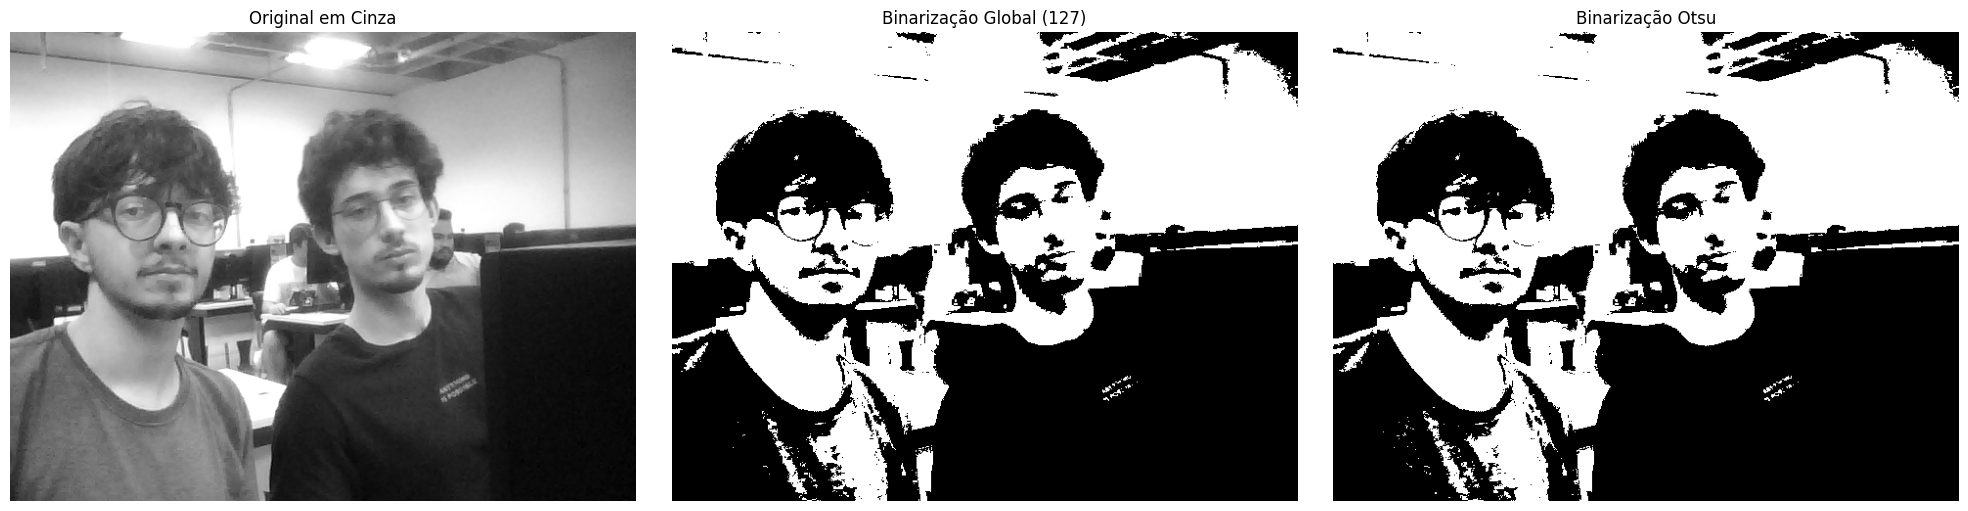

--- COMPARAÇÃO DE BINARIZAÇÃO ---


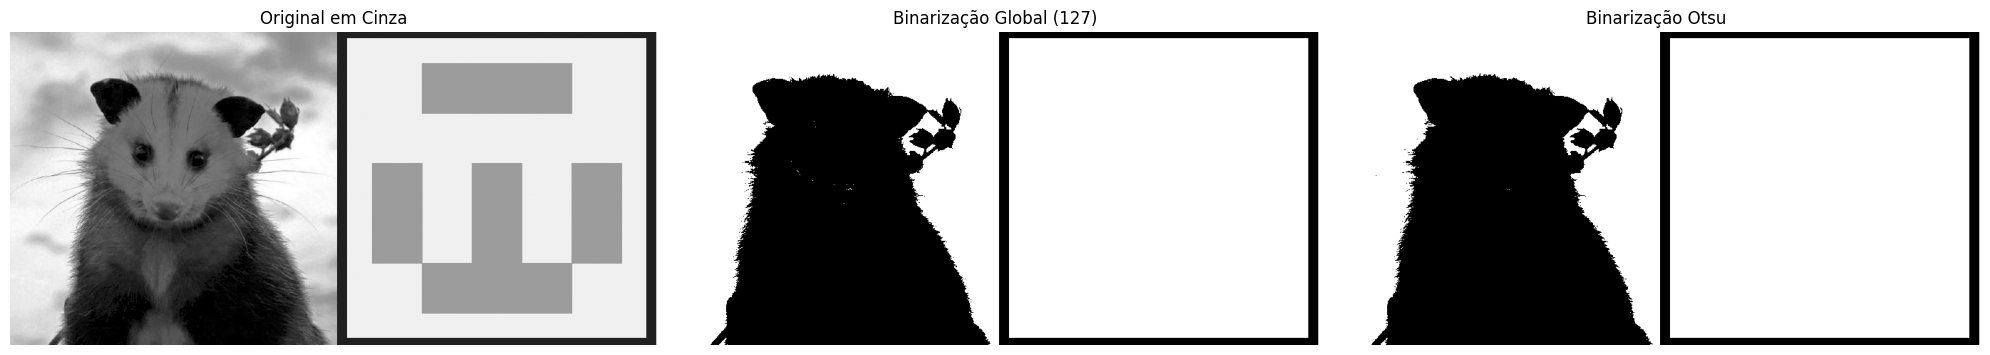


--- APLICANDO KERNEL 3x3 ---


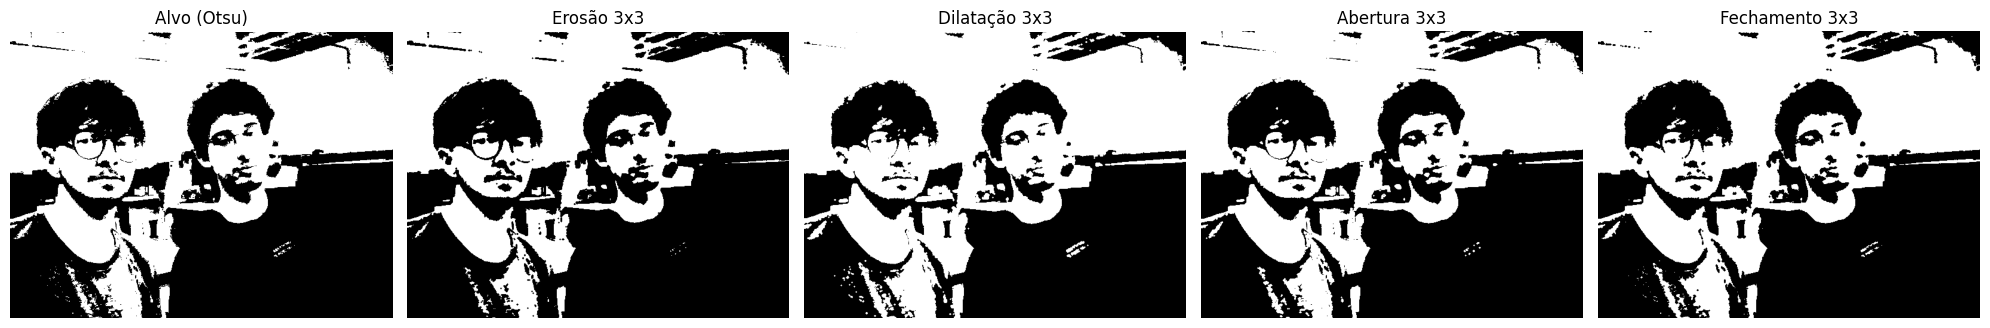


--- APLICANDO KERNEL 7x7 ---


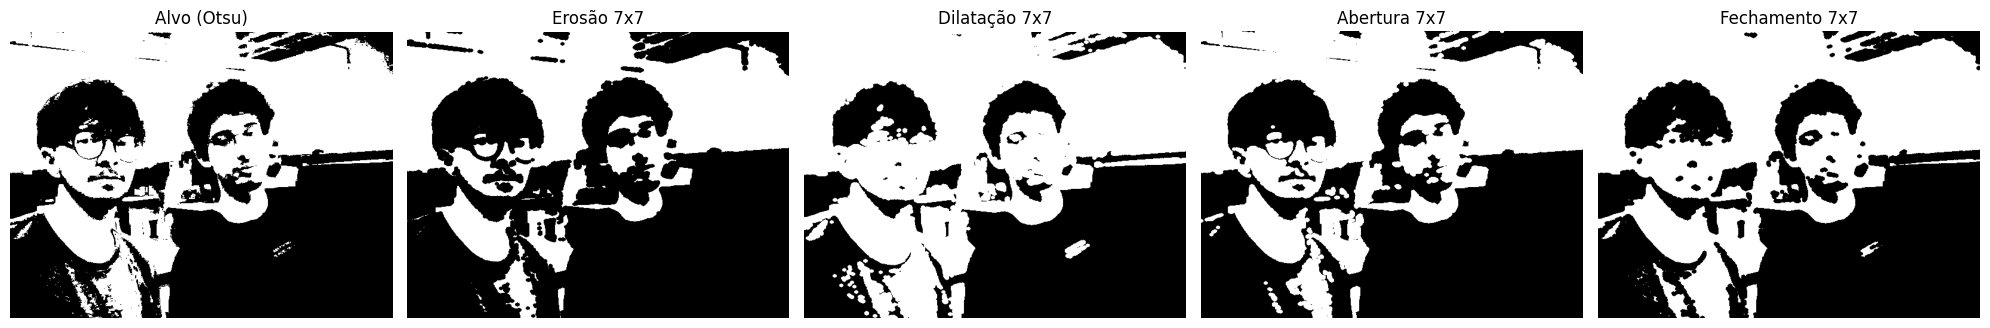


--- APLICANDO KERNEL 11x11 ---


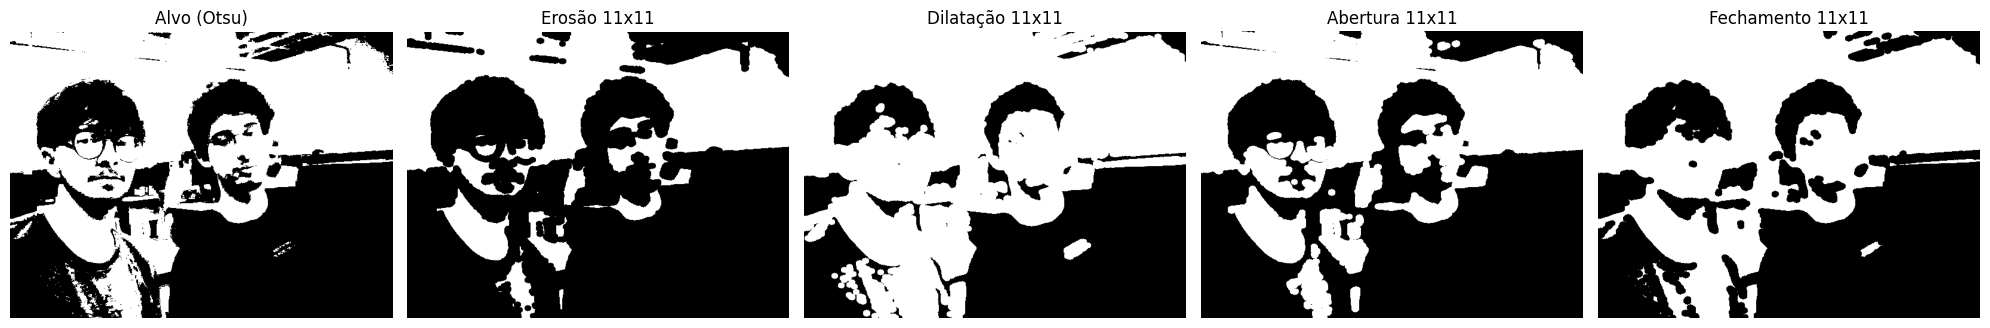


--- APLICANDO KERNEL 15x15 ---


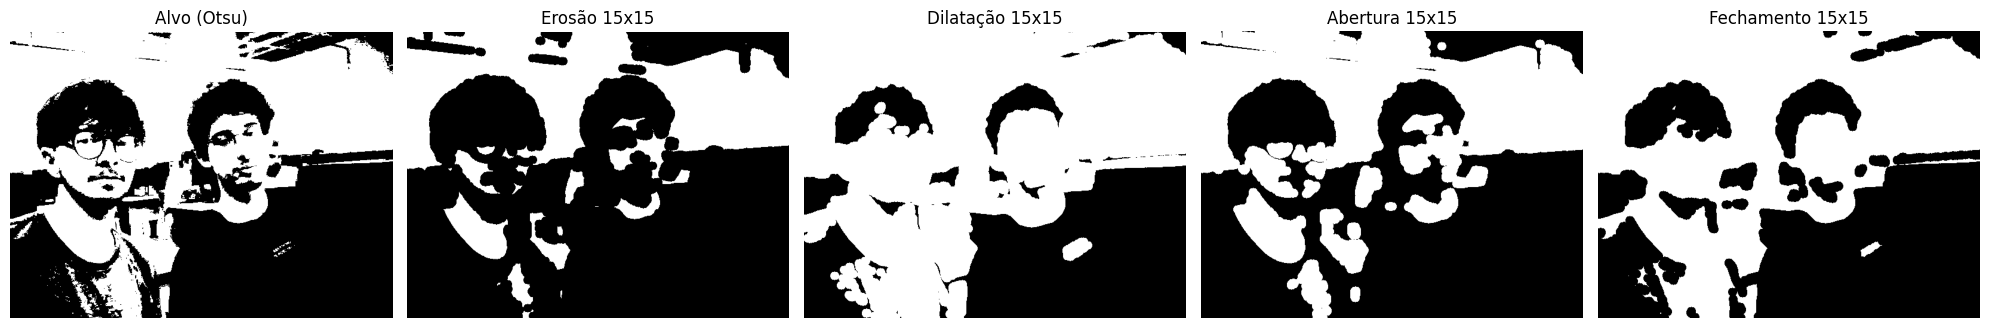


--- APLICANDO KERNEL 21x21 ---


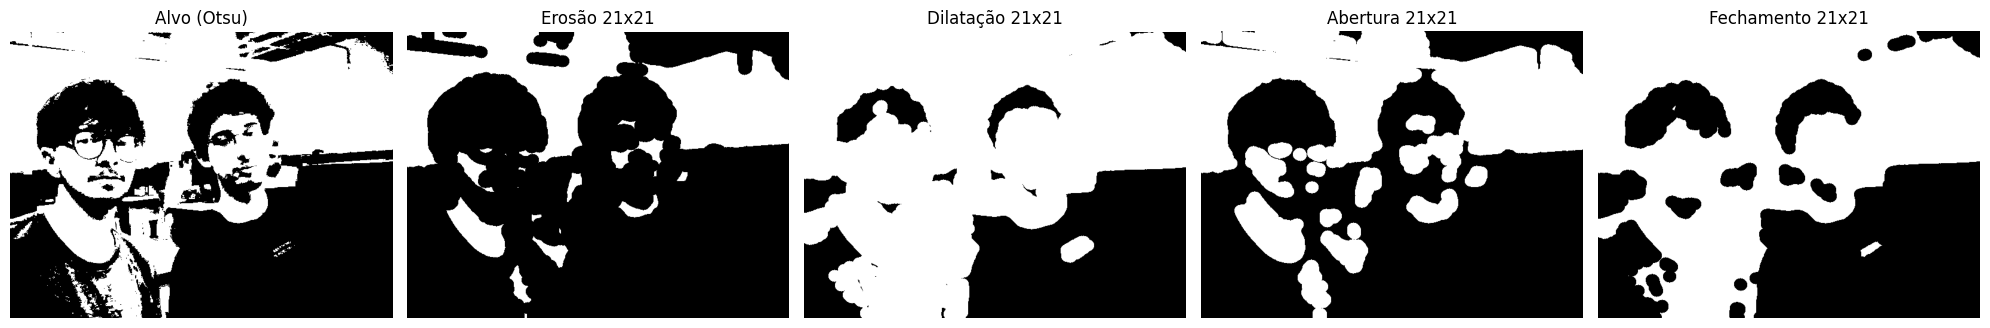


--- APLICANDO KERNEL 3x3 ---


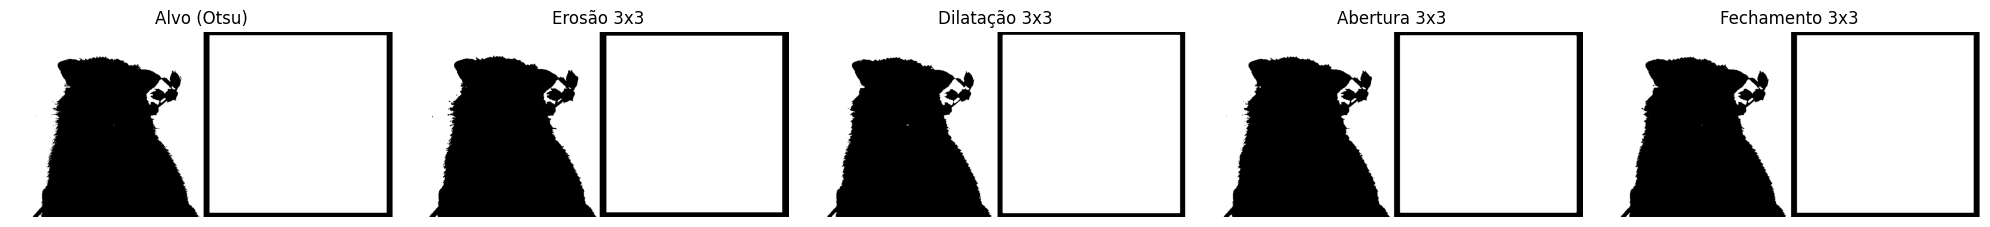


--- APLICANDO KERNEL 7x7 ---


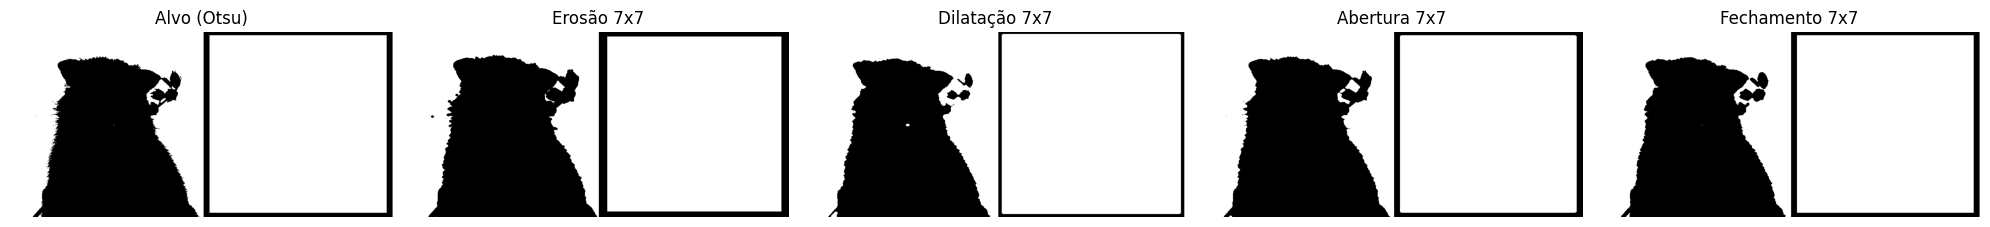


--- APLICANDO KERNEL 11x11 ---


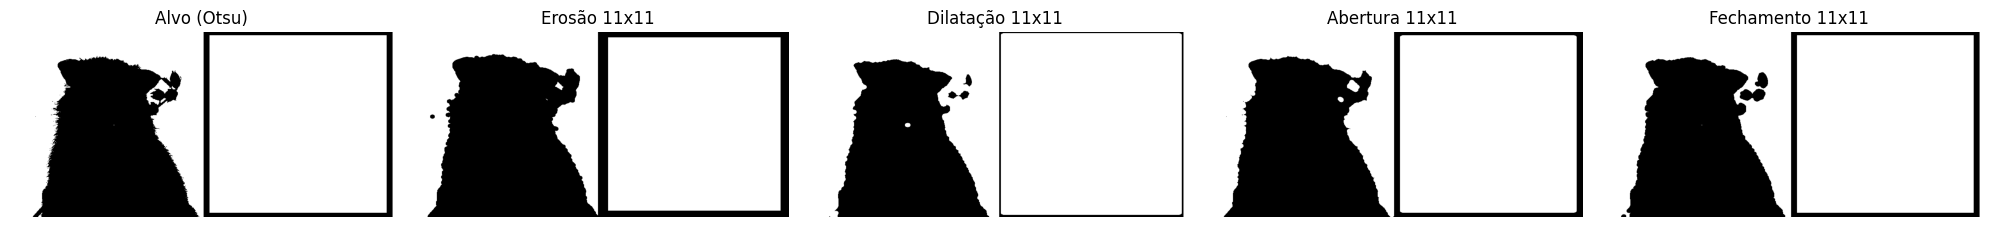


--- APLICANDO KERNEL 15x15 ---


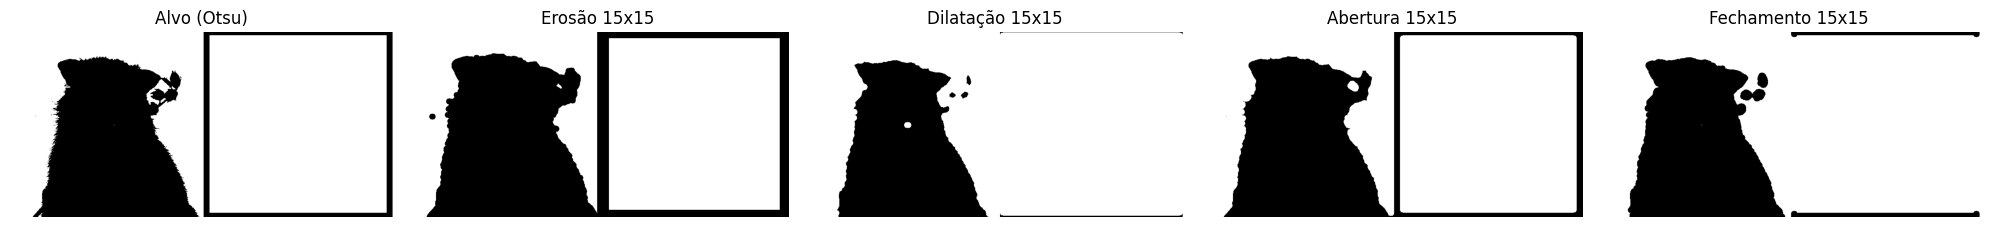


--- APLICANDO KERNEL 21x21 ---


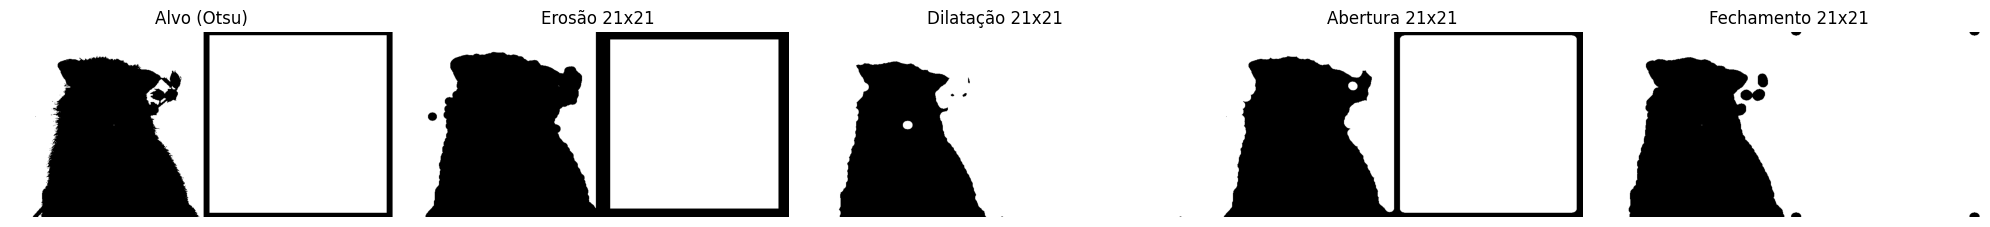

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar adaptada do seu laboratório
def exibir_imagens(imagens, titulos, figsize=(20, 5)):
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, tit in zip(axes, imagens, titulos):
        ax.imshow(img, cmap='gray')
        ax.set_title(tit)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 1. Carregamento da imagem alvo em tons de cinza
# Substitua 'foto1.png' pelo caminho correto se estiver em outra pasta
img_original = cv2.imread('foto1.png', cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print("Erro: Imagem 'foto1.png' não encontrada. Verifique o caminho.")
else:
    # 2. Análise da Binarização (Global vs Otsu)
    # Binarização Global (Limiar fixo em 127)
    _, img_bin_global = cv2.threshold(img_original, 127, 255, cv2.THRESH_BINARY)
    
    # Binarização de Otsu (Limiar adaptativo)
    _, img_bin_otsu = cv2.threshold(img_original, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    print("--- COMPARAÇÃO DE BINARIZAÇÃO ---")
    exibir_imagens(
        [img_original, img_bin_global, img_bin_otsu], 
        ["Original em Cinza", "Binarização Global (127)", "Binarização Otsu"]
    )
    
img_avatar = cv2.imread('avatar.png', cv2.IMREAD_GRAYSCALE)

if img_avatar is None:
    print("Erro: Imagem 'foto1.png' não encontrada. Verifique o caminho.")
else:
    # 2. Análise da Binarização (Global vs Otsu)
    # Binarização Global (Limiar fixo em 127)
    _, img_avatar_bin_global = cv2.threshold(img_avatar, 127, 255, cv2.THRESH_BINARY)
    
    # Binarização de Otsu (Limiar adaptativo)
    _, img_avatar_bin_otsu = cv2.threshold(img_avatar, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    print("--- COMPARAÇÃO DE BINARIZAÇÃO ---")
    exibir_imagens(
        [img_avatar, img_avatar_bin_global, img_avatar_bin_otsu], 
        ["Original em Cinza", "Binarização Global (127)", "Binarização Otsu"]
    )
    
    # Usaremos a imagem Otsu para as operações morfológicas, pois costuma lidar melhor com fotos reais.
    img_alvo = img_bin_otsu
    img_avatar_alvo = img_avatar_bin_otsu
    # 3. Operações Morfológicas com diferentes tamanhos de Kernel
    tamanhos_kernel = [3, 7, 11, 15, 21]
    
    for tamanho in tamanhos_kernel:
        print(f"\n--- APLICANDO KERNEL {tamanho}x{tamanho} ---")
        
        # Criando o elemento estruturante (usaremos o elíptico, que é melhor para formas orgânicas como rostos)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tamanho, tamanho))
        
        # Operações Básicas
        img_erosao = cv2.erode(img_alvo, kernel, iterations=1)
        img_dilatacao = cv2.dilate(img_alvo, kernel, iterations=1)
        
        # Operações Compostas (Abertura e Fechamento via cv2.morphologyEx)
        img_abertura = cv2.morphologyEx(img_alvo, cv2.MORPH_OPEN, kernel)
        img_fechamento = cv2.morphologyEx(img_alvo, cv2.MORPH_CLOSE, kernel)
        
        # Exibição dos resultados para este tamanho de kernel
        exibir_imagens(
            [img_alvo, img_erosao, img_dilatacao, img_abertura, img_fechamento],
            [f"Alvo (Otsu)", f"Erosão {tamanho}x{tamanho}", f"Dilatação {tamanho}x{tamanho}", f"Abertura {tamanho}x{tamanho}", f"Fechamento {tamanho}x{tamanho}"]
        )
        
    for tamanho in tamanhos_kernel:
        print(f"\n--- APLICANDO KERNEL {tamanho}x{tamanho} ---")
        
        # Criando o elemento estruturante (usaremos o elíptico, que é melhor para formas orgânicas como rostos)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tamanho, tamanho))
        
        # Operações Básicas
        img_erosao = cv2.erode(img_avatar_alvo, kernel, iterations=1)
        img_dilatacao = cv2.dilate(img_avatar_alvo, kernel, iterations=1)
        
        # Operações Compostas (Abertura e Fechamento via cv2.morphologyEx)
        img_abertura = cv2.morphologyEx(img_avatar_alvo, cv2.MORPH_OPEN, kernel)
        img_fechamento = cv2.morphologyEx(img_avatar_alvo, cv2.MORPH_CLOSE, kernel)
        
        # Exibição dos resultados para este tamanho de kernel
        exibir_imagens(
            [img_avatar_alvo, img_erosao, img_dilatacao, img_abertura, img_fechamento],
            [f"Alvo (Otsu)", f"Erosão {tamanho}x{tamanho}", f"Dilatação {tamanho}x{tamanho}", f"Abertura {tamanho}x{tamanho}", f"Fechamento {tamanho}x{tamanho}"]
        )
    

ELABORAÇÃO DE PROGRAMAS COM A WEBCAM:

(3.b)
Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações de Extração de Fronteiras (Gradiente Morfológico), mostrando na tela em tempo
real lado-a-lado a imagem original e a imagem extraída, permitindo ao operador escolher
– via teclado – a extração com diversos tamanhos de kernel. Grave um video demonstrativo
com os integrantes da equipe utilizando este programa com a webcam. Elabore uma
análise detalhada e explique os artefatos ocorridos.
Obs. O comando cv2.hconcat() une duas ou mais imagens horizontalmente (lado a lado),
desde que tenham a mesma altura. Ex.: resultado = cv2.hconcat([img1, img2])

In [4]:
import cv2
import numpy as np

# Inicia a captura de vídeo da webcam (0 é a câmera padrão)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Erro: Não foi possível acessar a webcam.")
    exit()

# Tamanho inicial do Kernel
k_size = 3

print("Pressione '+' (ou '=') para aumentar o kernel.")
print("Pressione '-' para diminuir o kernel.")
print("Pressione 'q' ou 'ESC' para sair e fechar a janela.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Erro ao capturar o frame.")
        break
    
    # Espelha a imagem para o movimento ficar natural (opcional)
    frame = cv2.flip(frame, 1)

    # Converte para tons de cinza (o gradiente morfológico funciona bem em cinza ou binarizado)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Garante que o tamanho do kernel seja no mínimo 1x1 e sempre ímpar
    if k_size < 3:
        k_size = 3
    elif k_size % 2 == 0:
        k_size += 1

    # Cria o elemento estruturante (Kernel)
    # Estamos usando MORPH_ELLIPSE por lidar melhor com contornos do corpo/rosto
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_size, k_size))
    
    # Aplica o Gradiente Morfológico (Dilatação - Erosão)
    gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)
    
    # Prepara a imagem original para ter texto (mantendo em cinza para facilitar a união)
    display_gray = gray.copy()
    
    # Textos na tela
    cv2.putText(display_gray, "Original", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 2)
    cv2.putText(gradient, f"Gradiente | Kernel: {k_size}x{k_size}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 2)
    
    # Une as duas imagens lado a lado, conforme solicitado
    resultado = cv2.hconcat([display_gray, gradient])
    
    # Exibe o resultado
    cv2.imshow("Webcam - Extracao de Fronteiras", resultado)
    
    # Captura as teclas pressionadas (espera 1ms)
    key = cv2.waitKey(1) & 0xFF
    
    if key == ord('q') or key == 27: # 'q' ou ESC para sair
        break
    elif key == ord('+') or key == ord('='):
        k_size += 2
    elif key == ord('-'):
        k_size -= 2

# Libera a câmera e fecha as janelas
cap.release()
cv2.destroyAllWindows()

Pressione '+' (ou '=') para aumentar o kernel.
Pressione '-' para diminuir o kernel.
Pressione 'q' ou 'ESC' para sair e fechar a janela.


Link do vídeo: https://drive.google.com/file/d/1DsbTS5X373_92VlAA4OIUBDsWbrpSLS6/view?usp=drive_link

### 4) Exercícios Propostos

(4.a). Elabore um programa para aplicar os operadores morfológicos imagens do seu
trabalho final, explicando o objetivo deste procedimento dentro do contexto da aplicação.

Analisando o Vaso 01...


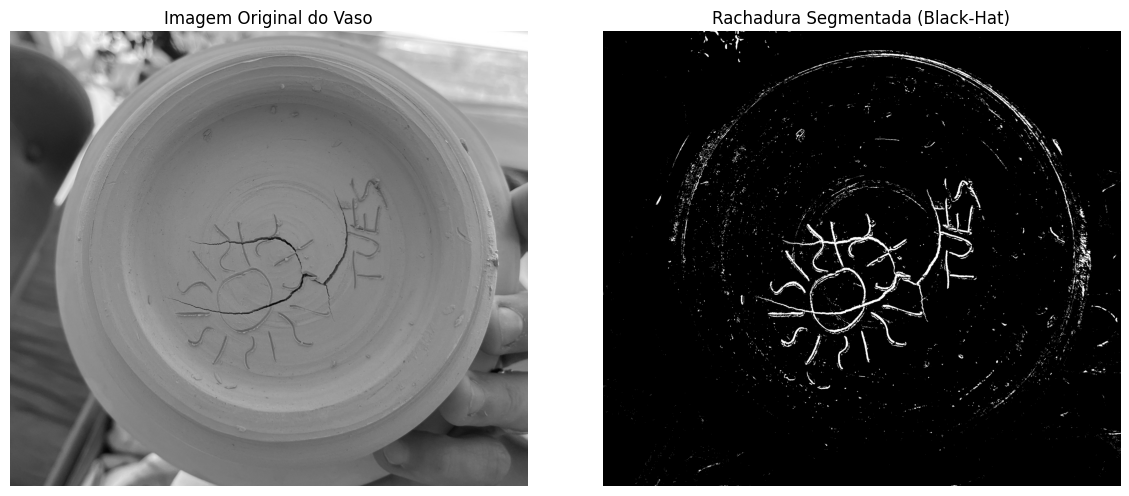


Analisando o Vaso 02...


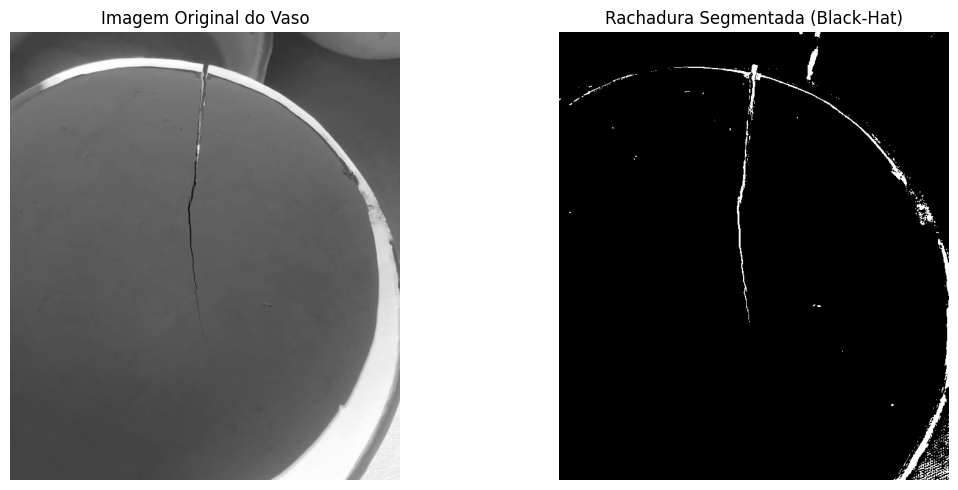

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def exibir_resultados(img_original, img_processada, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_original, cmap='gray')
    axes[0].set_title('Imagem Original do Vaso')
    axes[0].axis('off')
    
    axes[1].imshow(img_processada, cmap='gray')
    axes[1].set_title(titulo)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

def destacar_rachaduras(caminho_imagem):
    # 1. Carregar a imagem em tons de cinza
    img = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Erro: Não foi possível carregar a imagem '{caminho_imagem}'.")
        return

    # 2. Definição do Elemento Estruturante (Kernel)
    # Um kernel elíptico relativamente grande (ex: 15x15 ou 21x21) garante que 
    # ele seja maior que a espessura da rachadura, mas menor que a peça inteira.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))

    # 3. Aplicação do Black-Hat
    # O Black-Hat é a diferença entre o FECHAMENTO da imagem e a imagem ORIGINAL.
    img_blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

    # 4. Binarização para destacar a anomalia extraída
    # Limiar baixo porque o Black-Hat já jogou o fundo do vaso para tons quase pretos
    _, img_segmentada = cv2.threshold(img_blackhat, 15, 255, cv2.THRESH_BINARY)

    # Exibição
    exibir_resultados(img, img_segmentada, 'Rachadura Segmentada (Black-Hat)')

# Executando para as imagens do projeto
print("Analisando o Vaso 01...")
destacar_rachaduras('01.jpg')

print("\nAnalisando o Vaso 02...")
destacar_rachaduras('02.jpg')

A aplicação isolada de operações morfológicas simples, como Erosão ou Dilatação, falha ao inspecionar peças curvas porque elas afetam a imagem globalmente, amplificando as sombras naturais e os reflexos intensos causados pelo formato do vaso, o que acaba ocultando a rachadura fina ou criando grandes borrões escuros indesejados. Em contraste, a Transformada Black-Hat resolve esse problema atuando como um filtro extrator de anomalias: ela subtrai a imagem original de uma versão matematicamente "curada" pelo operador de Fechamento (que preenche e nivela temporariamente a falha). Ao calcular essa diferença, o algoritmo consegue ignorar completamente os gradientes de luz irregulares e o relevo normal da cerâmica, isolando com extrema precisão apenas as estruturas finas e escuras da rachadura, o que a torna a técnica ideal para viabilizar um sistema de inspeção automatizada robusto capaz de reduzir a fadiga visual dos operadores no chão de fábrica.

5) Questões de Análise do Processamento Morfológico de imagens: elabore as
respostas para cada uma das questoes abaixo em forma de texto e/ou figuras, e
apresente na parte de Análise e Discussão do relatório.

(5.a). Erosão e Estrutura: Ao aplicar uma erosão em uma imagem binária que contém
ruídos brancos (pontos isolados de 1 pixel) utilizando um kernel 3x3 de *uns*, o que
acontece com esses ruídos? Explique o porquê baseando-se no funcionamento do
operador.


--- APLICANDO KERNEL 3x3 DE 'UNS' ---


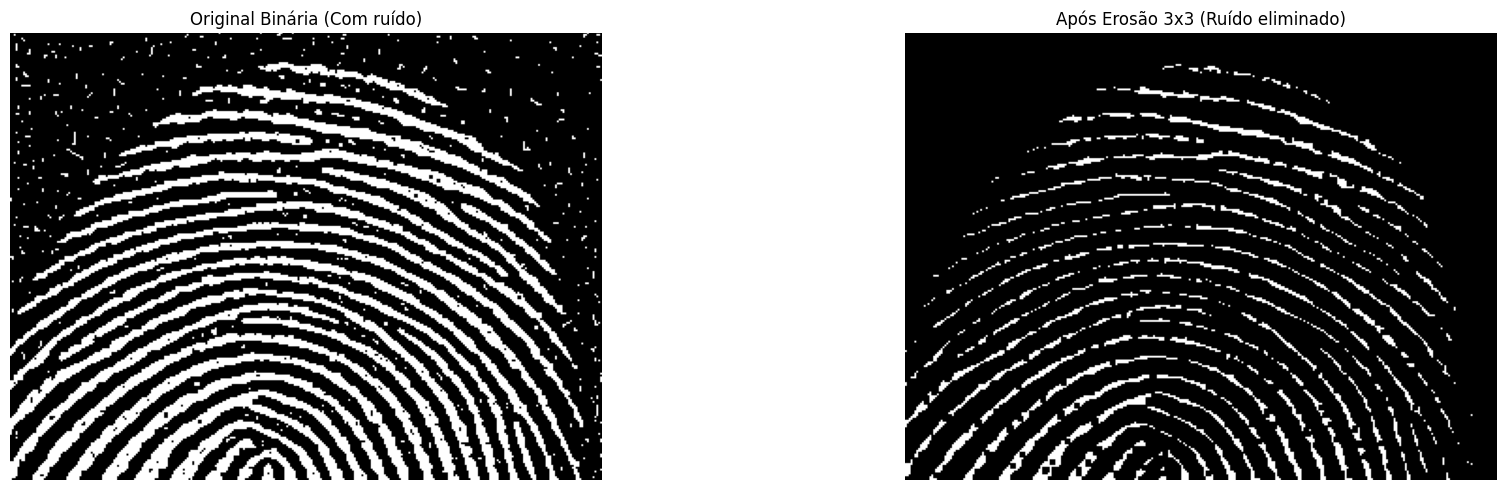

In [10]:
import cv2
import numpy as np

# 1. Carregar a imagem em tons de cinza
img_original = cv2.imread('noisy_fingerprint.png', cv2.IMREAD_GRAYSCALE)

# 2. Binarizar a imagem (Transformar em Preto e Branco puro)
# Isso garante que teremos os "ruídos brancos (pontos isolados)" do enunciado
_, img_alvo = cv2.threshold(img_original, 127, 255, cv2.THRESH_BINARY)

tamanho = 3

print(f"\n--- APLICANDO KERNEL {tamanho}x{tamanho} DE 'UNS' ---")

# 3. MODIFICAÇÃO PRINCIPAL: Criando o kernel de "uns" (matriz 3x3 preenchida com 1)
kernel = np.ones((tamanho, tamanho), np.uint8) 
# Alternativa do OpenCV: cv2.getStructuringElement(cv2.MORPH_RECT, (tamanho, tamanho))

# 4. Operação Básica pedida: EROSÃO
img_erosao = cv2.erode(img_alvo, kernel, iterations=1)

# Exibição dos resultados (usando a função exibir_imagens do seu notebook)
exibir_imagens(
    [img_alvo, img_erosao],
    ["Original Binária (Com ruído)", f"Após Erosão {tamanho}x{tamanho} (Ruído eliminado)"]
)

Os ruídos brancos (pontos isolados de 1 pixel) serão completamente eliminados (apagados e transformados em pixels pretos).

Por que isso acontece (O funcionamento do operador):
A operação de erosão funciona deslizando o elemento estruturante (seu kernel 3x3 cheio de uns) sobre a imagem, pixel por pixel. A regra lógica fundamental da erosão em imagens binárias é que o pixel central só permanecerá branco na imagem final se absolutamente todos os pixels da imagem que estão cobertos pelo kernel também forem brancos (funciona como uma porta lógica AND).

Como o ruído é apenas um ponto isolado de 1 pixel, ele está cercado por pixels pretos (fundo). Quando o centro do seu kernel 3x3 se posiciona exatamente sobre esse ponto de ruído, as bordas do kernel estarão cobrindo o fundo preto. Como nem todos os pixels sob o kernel são brancos, a condição falha, e o operador substitui aquele pixel central pelo valor mínimo encontrado na região (que é o preto). Assim, o ruído desaparece.

(5.b). Dilatação e Conectividade: Suponha que você tenha uma imagem de um texto
digitalizado onde as letras estão levemente "quebradas" ou fragmentadas. Qual o efeito
de aplicar uma dilatação com um elemento estruturante pequeno (ex: 3x3)? Existe
algum efeito colateral indesejado se o kernel for grande demais?

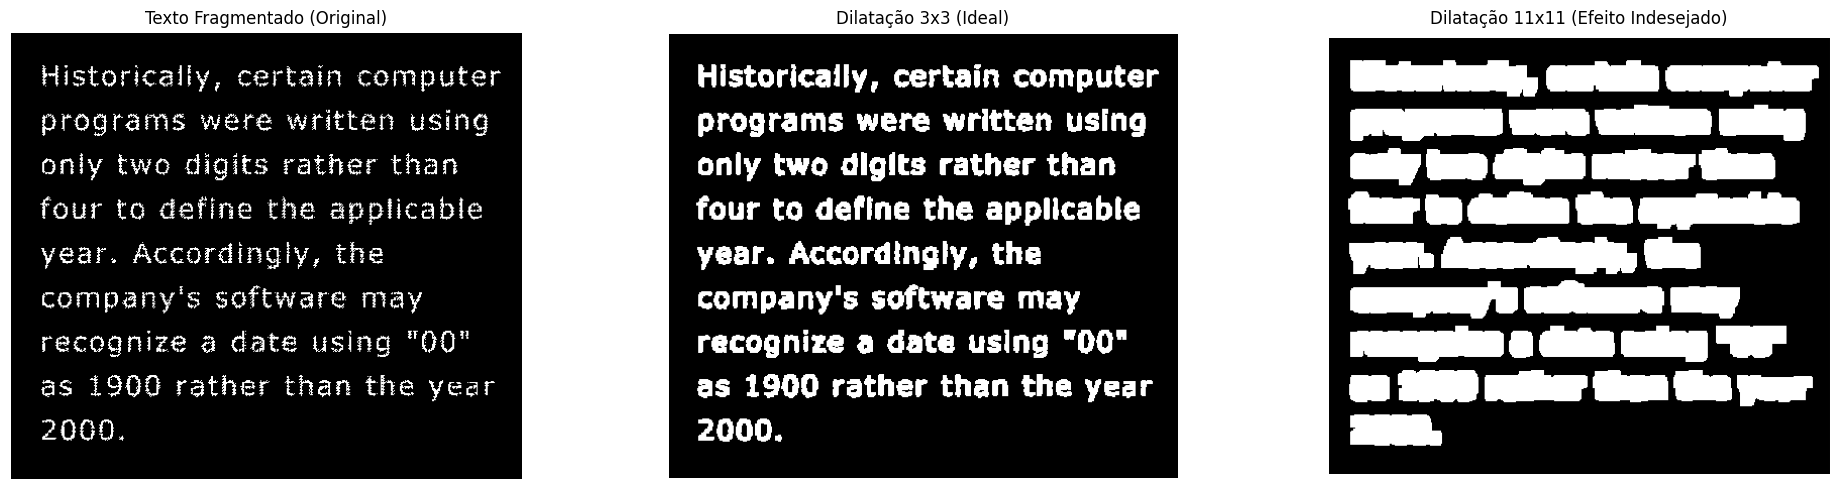

In [11]:
import cv2
import numpy as np

# 1. Carregar a imagem com falhas e garantir que é binária
# (Usada no seu laboratório original no exemplo de Closing)
img_txtgaps = cv2.imread('text_gaps_.png', cv2.IMREAD_GRAYSCALE)
_, img_bin = cv2.threshold(img_txtgaps, 127, 255, cv2.THRESH_BINARY)

# 2. Definir os Elementos Estruturantes
# Kernel 3x3 (Pequeno) e Kernel 11x11 (Exagerado)
kernel_pequeno = np.ones((3, 3), np.uint8)
kernel_grande = np.ones((11, 11), np.uint8)

# 3. Aplicar a Dilatação
img_dilatada_pequena = cv2.dilate(img_bin, kernel_pequeno, iterations=1)
img_dilatada_grande = cv2.dilate(img_bin, kernel_grande, iterations=1)

# 4. Exibir os resultados para comparação
exibir_imagens(
    [img_bin, img_dilatada_pequena, img_dilatada_grande],
    ['Texto Fragmentado (Original)', 'Dilatação 3x3 (Ideal)', 'Dilatação 11x11 (Efeito Indesejado)']
)

Efeito do kernel pequeno (3x3): A operação de dilatação expande as bordas dos pixels brancos (o texto). Ao usar um kernel pequeno como 3x3 em letras fragmentadas, essa leve expansão é suficiente para que as bordas dos pedaços soltos de uma mesma letra se toquem e se unam. O resultado é o preenchimento dessas microfalhas, restaurando a continuidade do traço e tornando a letra inteira e legível novamente.

Efeito colateral do kernel grande: Se o kernel for grande demais (como 11x11 ou 15x15), a expansão será excessiva. O efeito colateral indesejado é a fusão de caracteres. O operador deixará de preencher apenas as quebras internas das letras e passará a preencher os espaços em branco (fundo preto) que separam uma letra da outra, ou até mesmo os espaços entre as palavras. O texto se transformará em blocos brancos completamente ilegíveis (borrões).

(5.c). Extração de Contornos (Gradiente): A extração de fronteira pode ser feita
subtraindo a imagem erosionada da imagem original (A−(A⊖B)) .
 -- Prática: O que mudaria no contorno resultante se aumentássemos o tamanho do
elemento estruturante B de 3x3 para 11x11? 

O que mudaria: O contorno resultante ficaria muito mais espesso. Por que isso acontece: A extração de fronteira manual funciona subtraindo a imagem erosionada da imagem original. Quando você usa um kernel 3x3, a erosão "descasca" apenas uma camada de pixels da borda do objeto branco. Ao subtrair isso do original, o que sobra é exatamente essa fina camada de 1 pixel de espessura (um contorno fino e preciso).

Quando você aumenta o kernel para 11x11, a erosão se torna muito mais agressiva e "descasca" cinco camadas de pixels de uma vez para dentro do objeto. Ao subtrair essa imagem super encolhida do original, a diferença entre elas será uma borda muito larga, com 5 pixels de espessura.

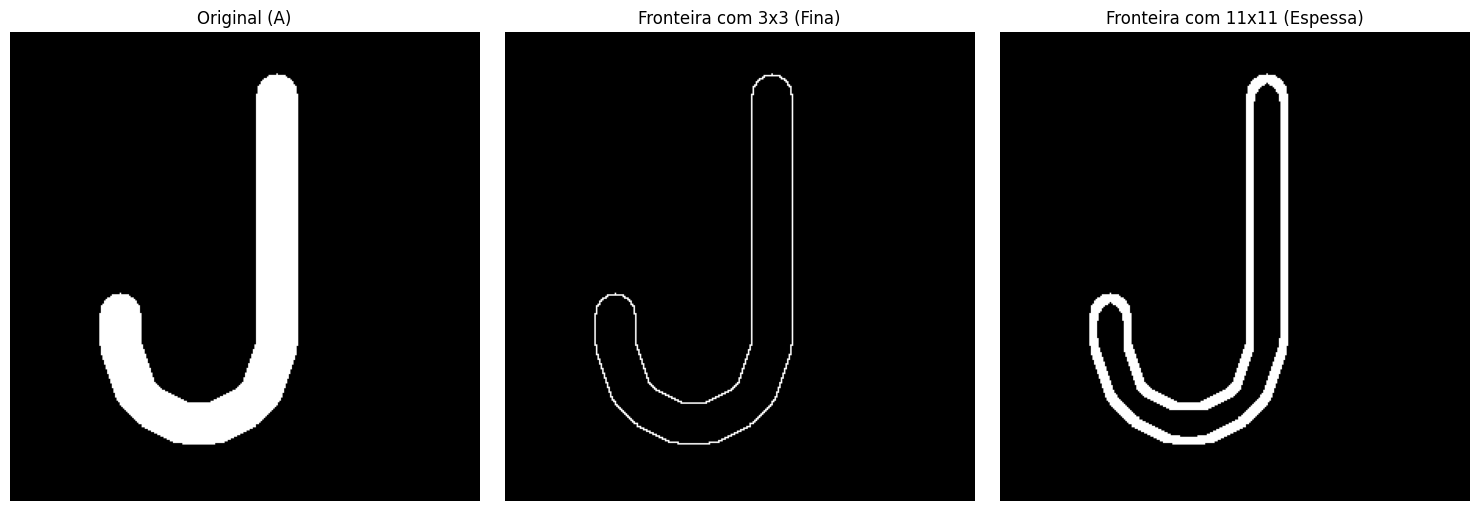

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar para exibir imagens (do seu laboratório)
def exibir_imagens(imagens, titulos):
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    if n == 1:
        axes = [axes]
    for ax, img, tit in zip(axes, imagens, titulos):
        ax.imshow(img, cmap='gray')
        ax.set_title(tit)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 1. Recriar a imagem binária do 'J' do laboratório
img_j = np.zeros((300, 300), dtype="uint8")
cv2.putText(img_j, 'J', (50, 250), cv2.FONT_HERSHEY_SIMPLEX, 10, 255, 25)
_, img_j_bin = cv2.threshold(img_j, 1, 255, cv2.THRESH_BINARY)

# 2. Criar os elementos estruturantes (kernels)
kernel_3x3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
kernel_11x11 = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))

# 3. Aplicar a Erosão
img_erosionada_3x3 = cv2.erode(img_j_bin, kernel_3x3, iterations=1)
img_erosionada_11x11 = cv2.erode(img_j_bin, kernel_11x11, iterations=1)

# 4. Extração de Fronteira: Original - Erosionada [ A - (A erosão B) ]
fronteira_3x3 = cv2.subtract(img_j_bin, img_erosionada_3x3)
fronteira_11x11 = cv2.subtract(img_j_bin, img_erosionada_11x11)

# 5. Visualizar a diferença
exibir_imagens(
    [img_j_bin, fronteira_3x3, fronteira_11x11],
    ['Original (A)', 'Fronteira com 3x3 (Fina)', 'Fronteira com 11x11 (Espessa)']
)

5.d). Abertura vs. Fechamento:
 * Qual dessas operações você utilizaria para remover pequenos objetos indesejados
(como poeira em um scan) sem alterar significativamente o tamanho dos objetos
principais?
 * Qual você utilizaria para fechar pequenos buracos ou fendas dentro de um objeto
sólido?

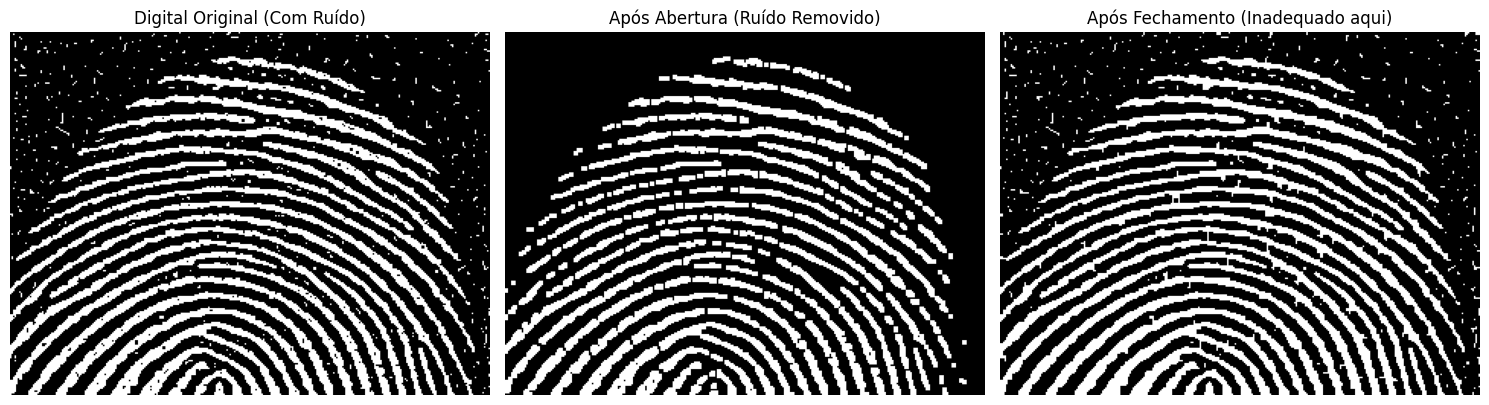

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar para exibir as imagens
def exibir_imagens(imagens, titulos):
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    if n == 1:
        axes = [axes]
    for ax, img, tit in zip(axes, imagens, titulos):
        ax.imshow(img, cmap='gray')
        ax.set_title(tit)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 1. Carregar a imagem da impressão digital em tons de cinza
img_fingerprint = cv2.imread('noisy_fingerprint.png', cv2.IMREAD_GRAYSCALE)

# 2. Criar um Elemento Estruturante (Kernel)
# Um kernel 3x3 quadrado costuma ser excelente para limpar pequenos ruídos
kernel = np.ones((3, 3), np.uint8)

# 3. Aplicar a Abertura (Opening)
# Objetivo: Remover pequenos ruídos brancos isolados preservando a estrutura principal
img_fp_opened = cv2.morphologyEx(img_fingerprint, cv2.MORPH_OPEN, kernel)

# 4. Aplicar o Fechamento (Closing) - Apenas para comparação
# Objetivo: Preencher buracos internos (na digital, pode acabar unindo as linhas se o kernel for grande)
img_fp_closed = cv2.morphologyEx(img_fingerprint, cv2.MORPH_CLOSE, kernel)

# 5. Exibir os resultados lado a lado para comparação
exibir_imagens(
    [img_fingerprint, img_fp_opened, img_fp_closed],
    ['Digital Original (Com Ruído)', 'Após Abertura (Ruído Removido)', 'Após Fechamento (Inadequado aqui)']
)

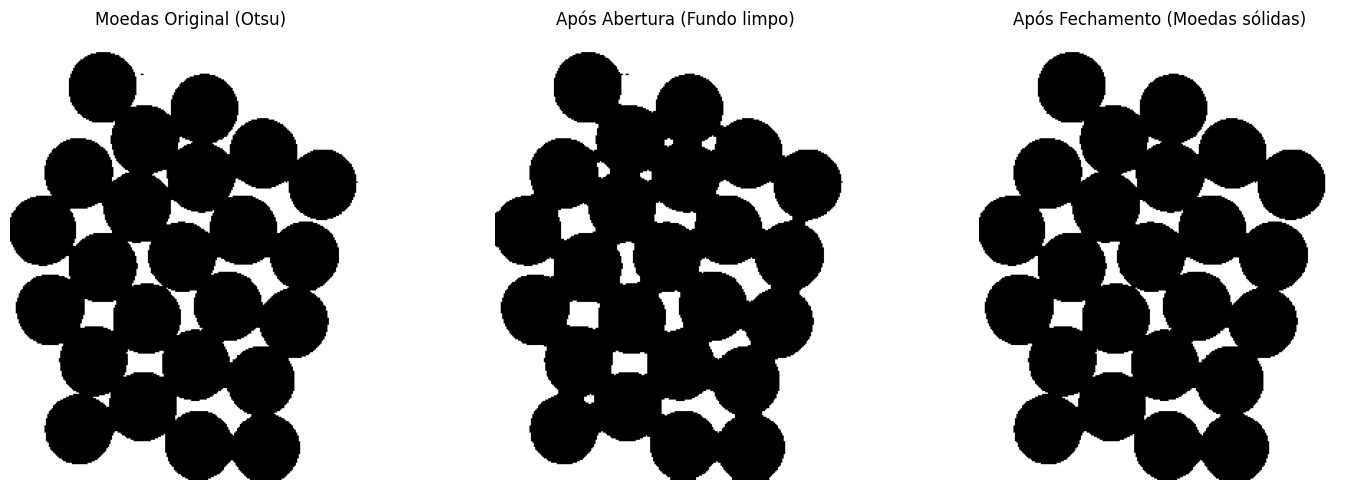

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar para exibir as imagens
def exibir_imagens(imagens, titulos):
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    if n == 1:
        axes = [axes]
    for ax, img, tit in zip(axes, imagens, titulos):
        ax.imshow(img, cmap='gray')
        ax.set_title(tit)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 1. Carregar a imagem das moedas e converter para tons de cinza
img_coins_color = cv2.imread('water_coins.png')
img_coins_gray = cv2.cvtColor(img_coins_color, cv2.COLOR_BGR2GRAY)

# 2. Binarizar usando o método de Otsu (ideal para fotos com iluminação variável)
_, img_coins_otsu = cv2.threshold(img_coins_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Criar um Elemento Estruturante (Kernel)
# Usaremos um kernel elíptico 5x5, pois as moedas são formas circulares orgânicas
kernel_ellip = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# 4. Aplicar a Abertura (Opening)
# Objetivo: Remover pequenos ruídos brancos isolados no fundo escuro (água)
img_coins_opened = cv2.morphologyEx(img_coins_otsu, cv2.MORPH_OPEN, kernel_ellip)

# 5. Aplicar o Fechamento (Closing)
# Objetivo: Preencher os buracos pretos (sombras/relevo) dentro das moedas brancas
img_coins_closed = cv2.morphologyEx(img_coins_otsu, cv2.MORPH_CLOSE, kernel_ellip)

# 6. Exibir os resultados lado a lado para comparação
exibir_imagens(
    [img_coins_otsu, img_coins_opened, img_coins_closed],
    ['Moedas Original (Otsu)', 'Após Abertura (Fundo limpo)', 'Após Fechamento (Moedas sólidas)']
)

Qual dessas operações você utilizaria para remover pequenos objetos indesejados (como poeira em um scan) sem alterar significativamente o tamanho dos objetos principais?
Qual você utilizaria para fechar pequenos buracos ou fendas dentro de um objeto sólido?

Para remover pequenos objetos indesejados (como poeira em um scan) sem alterar o tamanho dos objetos principais, você deve utilizar a Abertura (Opening). Como funciona: A abertura consiste em uma erosão seguida de uma dilatação.
Por que funciona: A erosão elimina completamente os detalhes que são menores que o elemento estruturante (a poeira some). A dilatação subsequente "restaura" os objetos grandes que foram levemente reduzidos pela erosão inicial, voltando-os ao tamanho original.

Para fechar pequenos buracos, lacunas ou fendas dentro de um objeto sólido, você deve utilizar o Fechamento (Closing). Como funciona: O fechamento consiste em uma dilatação seguida de uma erosão. Por que funciona: A dilatação expande os limites do objeto, fazendo com que as bordas das fendas ou buracos se toquem e se fundam. A erosão subsequente reduz o contorno externo do objeto de volta ao seu tamanho original, mas como os buracos internos foram "preenchidos" e deixaram de existir, eles não reaparecem.

(5.e). Análise de Kernel (Geometria): No código da Parte 2, definimos kernels
retangulares, elípticos e em cruz.
 *  Desafio Prático: Se você aplicar uma dilatação em um único pixel branco no centro
de uma imagem preta usando um “kernel_cross” (cruz), qual será o formato do objeto
resultante? E se usar o “kernel_rect”?

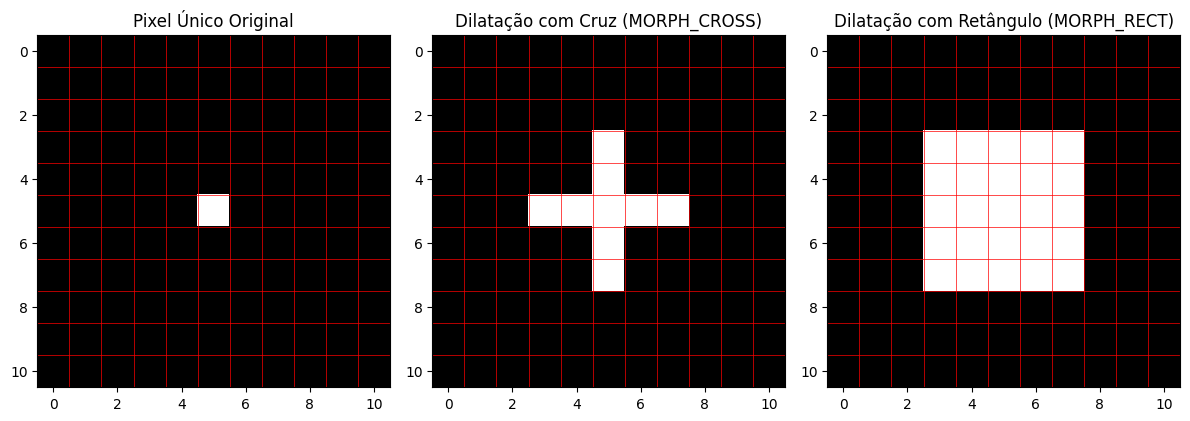

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar para exibição
def exibir_imagens(imagens, titulos):
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=(12, 4))
    if n == 1:
        axes = [axes]
    for ax, img, tit in zip(axes, imagens, titulos):
        ax.imshow(img, cmap='gray')
        ax.set_title(tit)
        
        # Ativando a grade (grid) para facilitar a visualização dos pixels
        ax.set_xticks(np.arange(-0.5, 11, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 11, 1), minor=True)
        ax.grid(which="minor", color="red", linestyle='-', linewidth=0.5)
        ax.tick_params(which="minor", size=0)
        
    plt.tight_layout()
    plt.show()

# 1. Criar uma imagem preta 11x11 e acender APENAS o pixel central (posição 5,5)
img_ponto = np.zeros((11, 11), dtype=np.uint8)
img_ponto[5, 5] = 255

# 2. Definir os kernels 5x5 do Laboratório (Cruz e Retângulo)
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# 3. Aplicar a dilatação sobre o ponto único
img_cross = cv2.dilate(img_ponto, kernel_cross, iterations=1)
img_rect = cv2.dilate(img_ponto, kernel_rect, iterations=1)

# 4. Exibir o resultado
exibir_imagens(
    [img_ponto, img_cross, img_rect],
    ['Pixel Único Original', 'Dilatação com Cruz (MORPH_CROSS)', 'Dilatação com Retângulo (MORPH_RECT)']
)

Ao aplicar uma dilatação em um único pixel branco no centro de uma imagem preta, o formato do objeto resultante será a cópia exata do elemento estruturante (kernel) utilizado, transformando-se em uma cruz ao usar o kernel_cross ou em um quadrado/retângulo maciço ao usar o kernel_rect. Isso acontece porque a operação de dilatação funciona centralizando o kernel sobre cada pixel branco encontrado na imagem original e "carimbando" o seu formato naquele local. Como existe apenas um pixel branco solitário na imagem de teste, o algoritmo aplica esse "carimbo" uma única vez, fazendo com que o resultado visual seja a estampa direta da própria matriz geométrica do kernel na tela.

### ***Conclusão***

Através das atividades práticas e experimentais desenvolvidas neste laboratório, foi possível consolidar a compreensão sobre os operadores de processamento morfológico de imagens. A análise das imagens demonstrou que a operação de erosão é eficaz para eliminar pixels brancos isolados (ruído), enquanto a dilatação expande as regiões de interesse e altera a espessura dos objetos com base no elemento estruturante (kernel) utilizado.

As operações compostas revelaram-se de grande utilidade: a abertura mostrou-se excelente na remoção de pequenos ruídos preservando a estrutura principal do objeto, conforme observado na análise da impressão digital. Além disso, a aplicação do Gradiente Morfológico em tempo real via webcam comprovou a sua robustez na extração de fronteiras e contornos de forma dinâmica. Em suma, os métodos morfológicos não apenas facilitam a filtragem e melhoria do aspeto visual das imagens, como também se revelam passos de pré-processamento fundamentais para a análise e deteção de características no contexto do trabalho final da equipa.

### ***Referências***

 **Rafael C. Gonzalez** . Digital Image Processing, Rafael C. Gonzalez . 4.ed. Pearson,
2018. Chapter 9 “Morphological Image Processing”.
<br>
Tutorial OpenCV e Python: Image Thresholding
https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
<br>
Image Thresholding in OpenCV. **Satya Mallick**, February 24, 2015:
https://learnopencv.com/opencv-threshold-python-cpp/